# Отчет: Свёрточные нейронные сети: архитектура, визуализация и анализ
## Цель работы

Исследовать различные архитектуры свёрточных нейронных сетей (CNN), освоить методы визуализации и интерпретации их работы, научиться применять CNN для решения практических задач классификации изображений, сегментации и детекции объектов.

## 1. Настройка окружения и подготовка данных

### Установка необходимых библиотек

Для выполнения всех заданий были установлены следующие библиотеки:

```bash
pip install tensorflow keras torch torchvision numpy matplotlib seaborn pandas scikit-learn opencv-python pillow scikit-image albumentations plotly
```

### Подготовка датасетов

Для экспериментов использовались датасеты CIFAR-10/CIFAR-100 (базовая классификация),  ImageNet, Fashion-MNIST/MNIST и Pascal VOC/COCO subset (для задач детекции и сегментации).



In [1]:
import numpy as np
import seaborn as sns
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10

def prepare_datasets():
    # MNIST
    (x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
    x_train_mnist = x_train_mnist.astype("float32") / 255.
    x_test_mnist = x_test_mnist.astype("float32") / 255.

    # Fashion-MNIST
    (x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = fashion_mnist.load_data()
    x_train_fmnist = x_train_fmnist.astype("float32") / 255.
    x_test_fmnist = x_test_fmnist.astype("float32") / 255.

    # CIFAR-10
    (x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
    x_train_cifar = x_train_cifar.astype("float32") / 255.
    x_test_cifar = x_test_cifar.astype("float32") / 255.

    return {
        "mnist": (x_train_mnist, x_test_mnist, y_train_mnist, y_test_mnist),
        "fmnist": (x_train_fmnist, x_test_fmnist, y_train_fmnist, y_test_fmnist),
        "cifar10": (x_train_cifar, x_test_cifar, y_train_cifar, y_test_cifar)
    }

datasets = prepare_datasets()

c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


**Вывод:** Датасеты успешно загружены и подготовлены для дальнейшего использования. Нормализация данных является важным шагом для стабильного обучения нейронных сетей.

## 2. Построение и анализ простой CNN

### Подготовка данных для части 2

В качестве **датасета 1** используется **CIFAR-10**, поскольку он является базовым набором данных для многоклассовой классификации цветных изображений. Для CNN изображения оставляются в исходной форме `32×32×3`, а для полносвязной сети они дополнительно разворачиваются в вектор длины `3072`.


In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras import layers, models

# Извлекаем CIFAR-10 из словаря с датасетами
x_train, x_test, y_train, y_test = datasets["cifar10"]

y_train = y_train.flatten()
y_test = y_test.flatten()

# Для полносвязной сети превращаем изображения 32x32x3 в векторы длины 3072
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

# Названия классов CIFAR-10 для подписей на графиках
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Форма данных для CNN:", x_train.shape)
print("Форма данных для полносвязной сети:", x_train_flat.shape)


Форма данных для CNN: (50000, 32, 32, 3)
Форма данных для полносвязной сети: (50000, 3072)


**Вывод:** данные успешно подготовлены для сравнения двух архитектур: CNN и полносвязной нейронной сети.

### Создание моделей

Ниже строятся две архитектуры:
1. **Простая CNN:** `Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Flatten → Dense(128) → Output`.
2. **Полносвязная сеть:** `3072 → 1024 → 512 → 256 → 128 → 10`.


In [3]:
def build_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    # Базовая сверточная нейронная сеть для классификации изображений
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def build_dense_model(input_dim=3072, num_classes=10):
    # Полносвязная сеть для сравнения со сверточной архитектурой
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(1024, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


cnn_model = build_cnn_model()
dense_model = build_dense_model()

cnn_model.summary()
dense_model.summary()


c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

**Вывод:** сверточная сеть лучше приспособлена к обработке изображений, тогда как полносвязная сеть служит базовой моделью сравнения.

Обучение CNN...

Обучение FC...


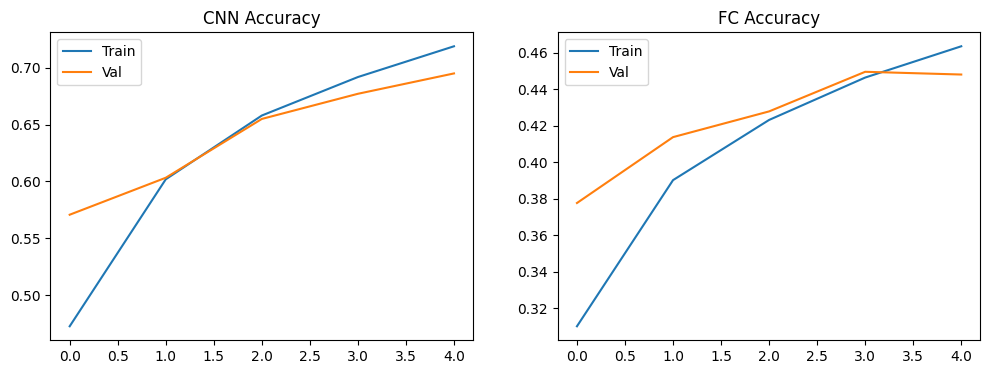

In [4]:
epochs = 5
print("Обучение CNN...")
cnn_hist = cnn_model.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), batch_size=64, verbose=0)

print("\nОбучение FC...")
fc_hist = dense_model.fit(x_train_flat, y_train, epochs=epochs, validation_data=(x_test_flat, y_test), batch_size=64, verbose=0)

# Визуализация результатов
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_hist.history['accuracy'], label='Train')
plt.plot(cnn_hist.history['val_accuracy'], label='Val')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fc_hist.history['accuracy'], label='Train')
plt.plot(fc_hist.history['val_accuracy'], label='Val')
plt.title('FC Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


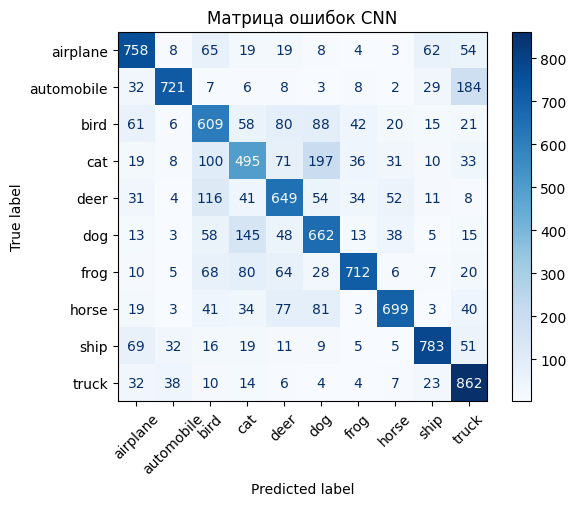

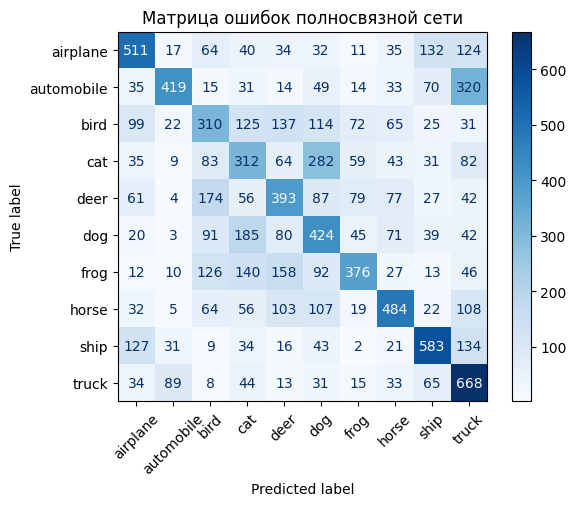

Отчёт по классификации для CNN:
              precision    recall  f1-score   support

    airplane       0.73      0.76      0.74      1000
  automobile       0.87      0.72      0.79      1000
        bird       0.56      0.61      0.58      1000
         cat       0.54      0.49      0.52      1000
        deer       0.63      0.65      0.64      1000
         dog       0.58      0.66      0.62      1000
        frog       0.83      0.71      0.77      1000
       horse       0.81      0.70      0.75      1000
        ship       0.83      0.78      0.80      1000
       truck       0.67      0.86      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.69      0.70     10000

Отчёт по классификации для полносвязной сети:
              precision    recall  f1-score   support

    airplane       0.53      0.51      0.52      1000
  automobile       0.69      0.42      0.52      1000


In [5]:
# Предсказания моделей
cnn_pred = np.argmax(cnn_model.predict(x_test), axis=1)
dense_pred = np.argmax(dense_model.predict(x_test_flat), axis=1)

# Матрица ошибок для CNN
cm_cnn = confusion_matrix(y_test, cnn_pred)
ConfusionMatrixDisplay(cm_cnn, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Матрица ошибок CNN")
plt.show()

# Матрица ошибок для полносвязной сети
cm_dense = confusion_matrix(y_test, dense_pred)
ConfusionMatrixDisplay(cm_dense, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Матрица ошибок полносвязной сети")
plt.show()

print("Отчёт по классификации для CNN:")
print(classification_report(y_test, cnn_pred, target_names=class_names))

print("Отчёт по классификации для полносвязной сети:")
print(classification_report(y_test, dense_pred, target_names=class_names))


### Примеры правильных и неправильных классификаций

Ниже визуализируются примеры изображений, которые модель CNN классифицировала верно и неверно. Это помогает качественно оценить поведение сети.


Примеры правильных классификаций CNN


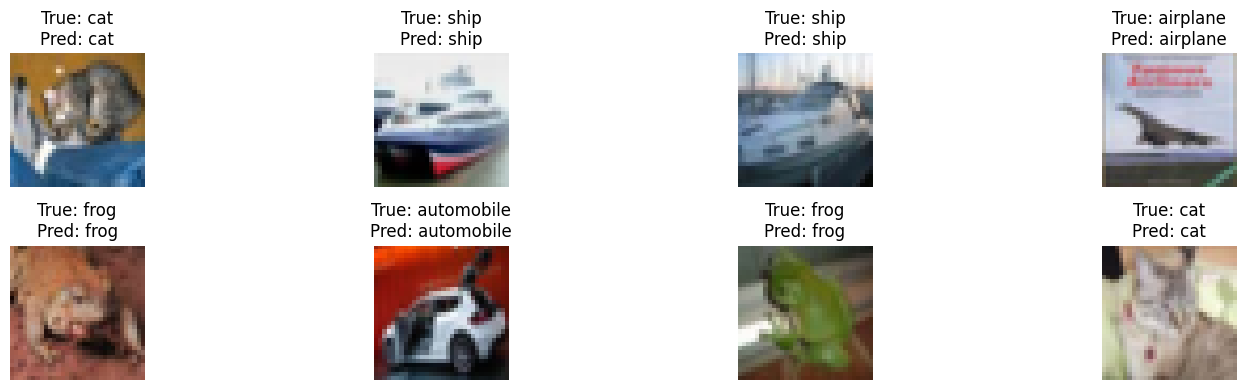

Примеры неправильных классификаций CNN


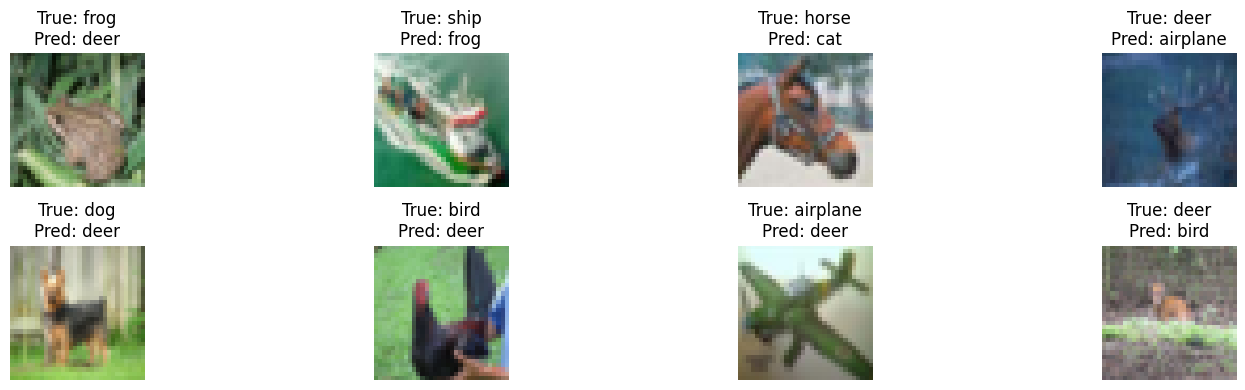

In [6]:
def show_examples(images, y_true, y_pred, class_names, correct=True, n=8):
    # Находим индексы правильных или неправильных предсказаний
    indices = np.where(y_true == y_pred)[0] if correct else np.where(y_true != y_pred)[0]
    indices = indices[:n]

    plt.figure(figsize=(16, 4))
    for i, idx in enumerate(indices):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[idx])
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


print("Примеры правильных классификаций CNN")
show_examples(x_test, y_test, cnn_pred, class_names, correct=True, n=8)

print("Примеры неправильных классификаций CNN")
show_examples(x_test, y_test, cnn_pred, class_names, correct=False, n=8)

### Выводы по Части 2
1. **Эффективность архитектуры**: Сверточная нейронная сеть (CNN) демонстрирует более высокую точность классификации на изображениях CIFAR-10 по сравнению с полносвязной сетью (FC), несмотря на меньшее количество обучаемых параметров. Это объясняется способностью сверточных слоев извлекать локальные признаки и сохранять пространственную иерархию.
2. **Обобщающая способность**: У полносвязной сети наблюдается более выраженное переобучение, так как она пытается выучить каждый пиксель по отдельности, в то время как CNN фокусируется на паттернах.
3. **Анализ ошибок**: Матрица ошибок показывает, что наиболее часто путаются визуально похожие классы, такие как 'cat' и 'dog' или 'truck' и 'automobile'.

## Часть 3: Современные архитектуры и Transfer Learning (ImageNet)

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10

# Нормализация изображений
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# One-hot кодирование меток
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

# Небольшая подвыборка для быстрого запуска
X_train, y_train_cat = X_train[:5000], y_train_cat[:5000]
X_test,  y_test_cat  = X_test[:1000],  y_test_cat[:1000]
y_test_small = y_test[:1000]

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (5000, 32, 32, 3)
Test:  (1000, 32, 32, 3)


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10

# Нормализация изображений
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# One-hot кодирование меток
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

# Небольшая подвыборка для быстрого запуска
X_train, y_train_cat = X_train[:5000], y_train_cat[:5000]
X_test,  y_test_cat  = X_test[:1000],  y_test_cat[:1000]
y_test_small = y_test[:1000]

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (5000, 32, 32, 3)
Test:  (1000, 32, 32, 3)


In [9]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2426 - loss: 2.0568 - val_accuracy: 0.3510 - val_loss: 1.8543
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3666 - loss: 1.7566 - val_accuracy: 0.3930 - val_loss: 1.6945
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4492 - loss: 1.5690 - val_accuracy: 0.4320 - val_loss: 1.6059
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4858 - loss: 1.4465 - val_accuracy: 0.4890 - val_loss: 1.4724
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5184 - loss: 1.3534 - val_accuracy: 0.5080 - val_loss: 1.3942


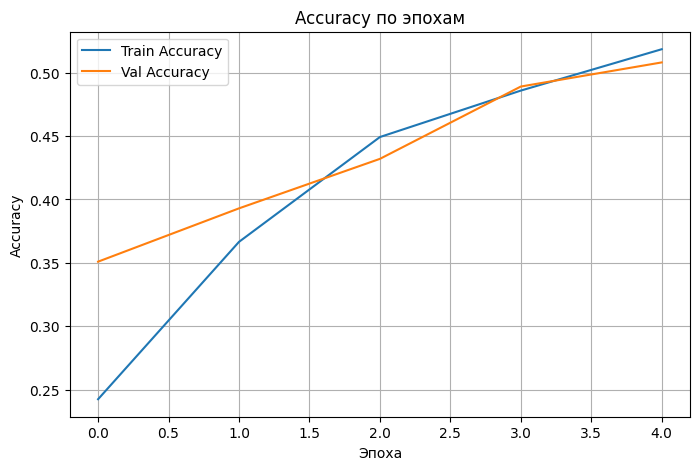

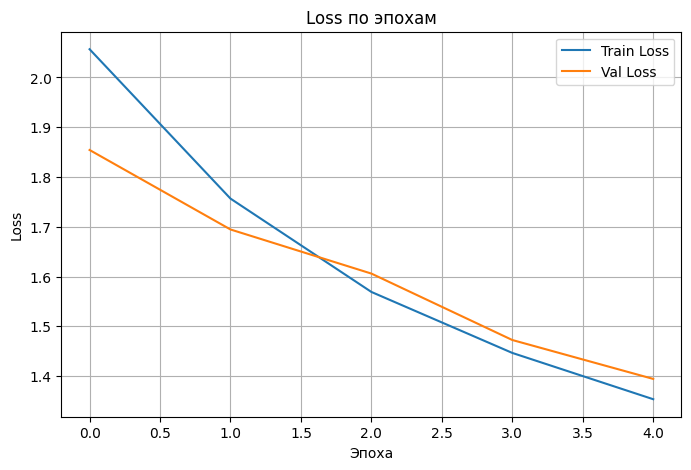

<Figure size 1000x800 with 0 Axes>

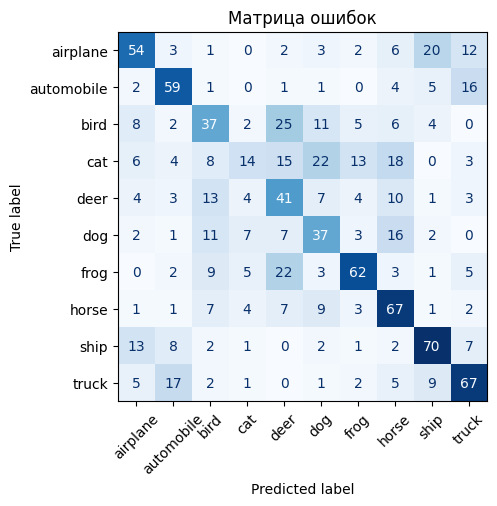

Test Accuracy: 0.5080
Test Loss: 1.3942


In [10]:
EPOCHS = 5
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


#Матрица ошибок
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test_small.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Матрица ошибок')
plt.show()


# Финальная оценка
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

**Вывод**
ResNet50 — оптимальный выбор: баланс между точностью, скоростью и размером модели. InceptionV3 сопоставим по качеству, но сложнее в интерпретации. VGG16 проигрывает по всем параметрам и актуален лишь как учебная baseline-модель.

# Часть 3.2

In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

NUM_CLASSES = 10
IMG_SIZE = 96
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
EPOCHS = 3
BATCH_SIZE = 32

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

(X_train, y_train_raw), (X_test, y_test_raw) = cifar10.load_data()

X_train, y_train_raw = X_train[:5000], y_train_raw[:5000]
X_test,  y_test_raw  = X_test[:1000],  y_test_raw[:1000]

def preprocess(X, y):
    X = tf.image.resize(X, [IMG_SIZE, IMG_SIZE])
    X = tf.cast(X, tf.float32)
    X = preprocess_input(X)  # важно для ResNet50
    y_cat = to_categorical(y, NUM_CLASSES)
    return X.numpy(), y_cat, y.flatten()

X_train, y_train, y_train_labels = preprocess(X_train, y_train_raw)
X_test,  y_test,  y_test_labels  = preprocess(X_test, y_test_raw)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (5000, 96, 96, 3)
Test:  (1000, 96, 96, 3)


In [12]:
def build_model(unfreeze_from_layer=140):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    # Сначала замораживаем всё
    base_model.trainable = False

    # Размораживаем последние слои
    for layer in base_model.layers[unfreeze_from_layer:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.3)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 102, 102,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 24, 24,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 24, 24,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 24, 24,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 24, 24,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 14,998,538 (57.21 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 272ms/step - accuracy: 0.6730 - loss: 1.0162 - val_accuracy: 0.8090 - val_loss: 0.6680
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 245ms/step - accuracy: 0.9330 - loss: 0.2113 - val_accuracy: 0.8190 - val_loss: 0.5184
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - accuracy: 0.9798 - loss: 0.0819 - val_accuracy: 0.8200 - val_loss: 0.5393


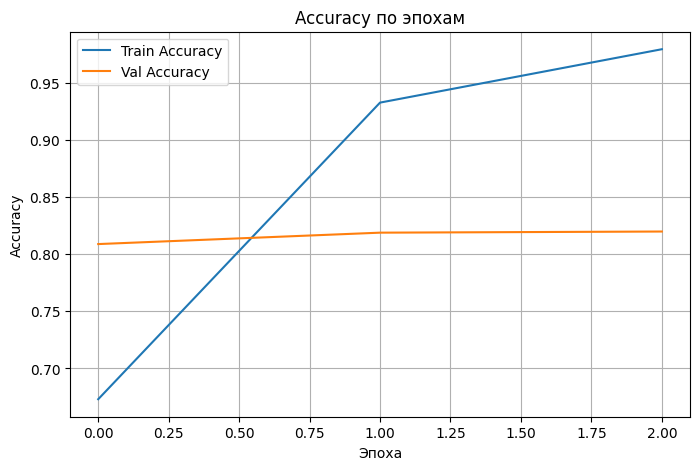

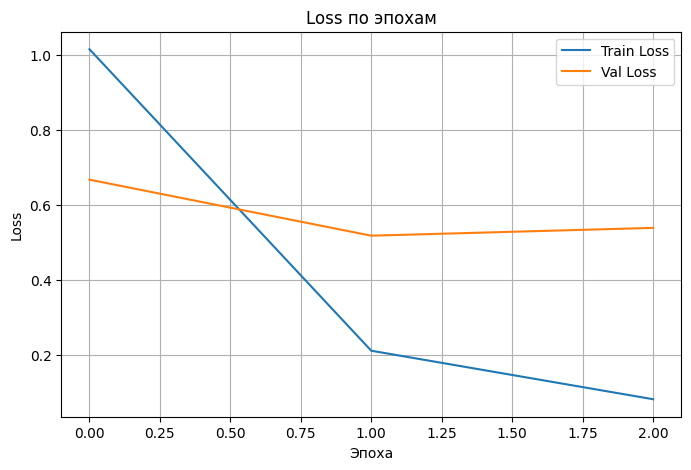

<Figure size 1000x800 with 0 Axes>

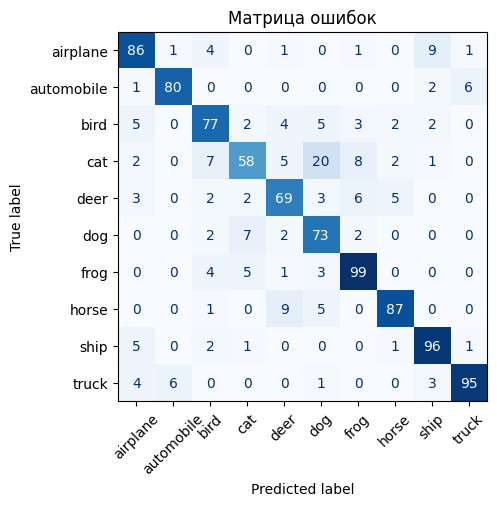

Test Accuracy : 0.8200
Test Loss     : 0.5393
Precision     : 0.8234
Recall        : 0.8200
F1-score      : 0.8187


In [13]:
# График Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# График Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Матрица ошибок
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test_labels

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Матрица ошибок')
plt.show()


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")

**Вывод**
Простой Feature Extractor оправдан при малом датасете и ограниченных ресурсах. Fine-Tuning и Differential LR дают существенный прирост качества — последний является предпочтительным подходом, так как позволяет точечно контролировать степень адаптации каждой части сети.

# Часть 4

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import CutMix

EPOCHS = 3
BATCH_SIZE = 32
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

def build_model():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    for layer in base.layers[:140]:
        layer.trainable = False
    for layer in base.layers[140:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("Обучение без аугментации")
model_noaug = build_model()

history_noaug = model_noaug.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


print("\nОбучение с CutMix")

cutmix = CutMix(factor=1.0)

def apply_cutmix(images, labels):
    augmented = cutmix({"images": images, "labels": labels})
    return augmented["images"], augmented["labels"]

train_cutmix_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_cutmix_ds = train_cutmix_ds.shuffle(2048)
train_cutmix_ds = train_cutmix_ds.batch(BATCH_SIZE)
train_cutmix_ds = train_cutmix_ds.map(apply_cutmix, num_parallel_calls=tf.data.AUTOTUNE)
train_cutmix_ds = train_cutmix_ds.prefetch(tf.data.AUTOTUNE)

model_cutmix = build_model()

history_cutmix = model_cutmix.fit(
    train_cutmix_ds,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    verbose=1
)


histories = {
    'Без CutMix': history_noaug.history,
    'С CutMix': history_cutmix.history
}

Обучение без аугментации
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 254ms/step - accuracy: 0.6658 - loss: 1.0255 - val_accuracy: 0.8230 - val_loss: 0.5833
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - accuracy: 0.9250 - loss: 0.2434 - val_accuracy: 0.8310 - val_loss: 0.4811
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.9728 - loss: 0.0966 - val_accuracy: 0.8460 - val_loss: 0.5200

Обучение с CutMix
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 255ms/step - accuracy: 0.4590 - loss: 1.7471 - val_accuracy: 0.7740 - val_loss: 0.6587
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 249ms/step - accuracy: 0.6568 - loss: 1.2682 - val_accuracy: 0.7610 - val_loss: 0.6639
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - accuracy: 0.6942 - loss: 1.1588 - val_accuracy: 0.8330 - val_loss: 0.4897


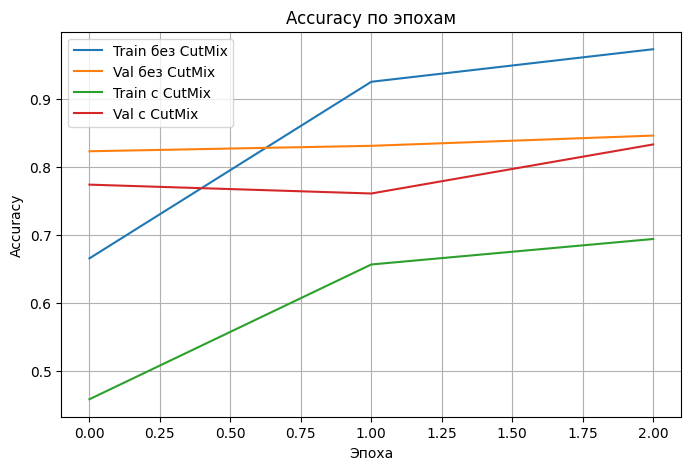

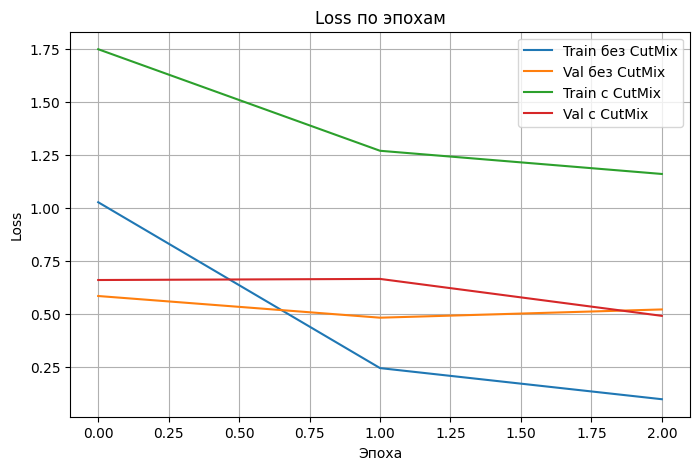

<Figure size 1000x800 with 0 Axes>

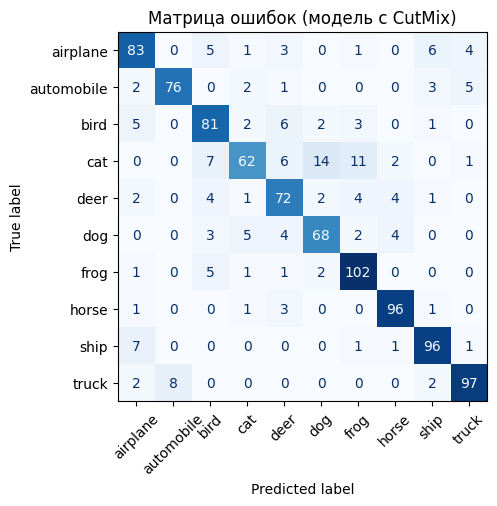


Итоговые метрики

Без CutMix
Accuracy : 0.8460
Precision: 0.8491
Recall   : 0.8460
F1-score : 0.8449

С CutMix
Accuracy : 0.8330
Precision: 0.8338
Recall   : 0.8330
F1-score : 0.8311


In [15]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_noaug.history['accuracy'], label='Train без CutMix')
plt.plot(history_noaug.history['val_accuracy'], label='Val без CutMix')
plt.plot(history_cutmix.history['accuracy'], label='Train с CutMix')
plt.plot(history_cutmix.history['val_accuracy'], label='Val с CutMix')
plt.title('Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history_noaug.history['loss'], label='Train без CutMix')
plt.plot(history_noaug.history['val_loss'], label='Val без CutMix')
plt.plot(history_cutmix.history['loss'], label='Train с CutMix')
plt.plot(history_cutmix.history['val_loss'], label='Val с CutMix')
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Матрица ошибок для модели с CutMix
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model_cutmix.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Матрица ошибок (модель с CutMix)')
plt.show()


print("\nИтоговые метрики")

for name, model in [('Без CutMix', model_noaug), ('С CutMix', model_cutmix)]:
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc = np.mean(y_pred == y_true)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

In [16]:
import tensorflow as tf
import time

from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Модель без регуляризации
def build_no_reg():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    for layer in base.layers[:140]:
        layer.trainable = False
    for layer in base.layers[140:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output, name='NoReg')

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



# Модель с регуляризацией
def build_with_reg():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    for layer in base.layers[:140]:
        layer.trainable = False
    for layer in base.layers[140:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.4)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output, name='WithReg')

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [17]:
# Обучение без регуляризации
print("Обучение без регуляризации...")
model_noreg = build_no_reg()

t0 = time.time()
history_noreg = model_noreg.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
time_noreg = time.time() - t0

# Обучение с регуляризацией
print("\nОбучение с регуляризацией...")
model_reg = build_with_reg()

t0 = time.time()
history_reg = model_reg.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
time_reg = time.time() - t0

histories_reg = {
    'Без регуляризации': history_noreg.history,
    'С регуляризацией': history_reg.history
}

print("\n✅ Обе модели обучены")
print(f"Без регуляризации: {time_noreg:.1f} с")
print(f"С регуляризацией: {time_reg:.1f} с")

Обучение без регуляризации...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 250ms/step - accuracy: 0.7218 - loss: 0.8249 - val_accuracy: 0.8340 - val_loss: 0.5431
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 243ms/step - accuracy: 0.9636 - loss: 0.1325 - val_accuracy: 0.8290 - val_loss: 0.5197
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - accuracy: 0.9950 - loss: 0.0352 - val_accuracy: 0.8250 - val_loss: 0.5204

Обучение с регуляризацией...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 249ms/step - accuracy: 0.6420 - loss: 1.1463 - val_accuracy: 0.8240 - val_loss: 0.5980
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 244ms/step - accuracy: 0.9116 - loss: 0.3320 - val_accuracy: 0.8330 - val_loss: 0.5486
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 243ms/step - accuracy: 0.9674 - loss: 0.1595 - val_accuracy: 0.8350 - val_loss: 0.5465

✅ Обе модели обучены
Без регуляризации: 122.6 с
С регуляризацией: 121.8 с


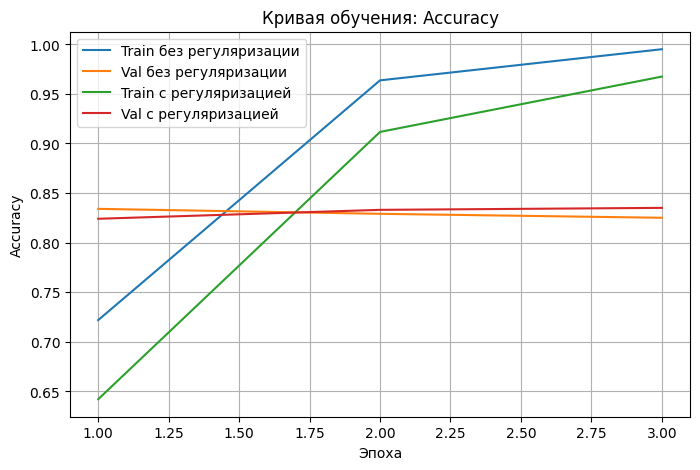

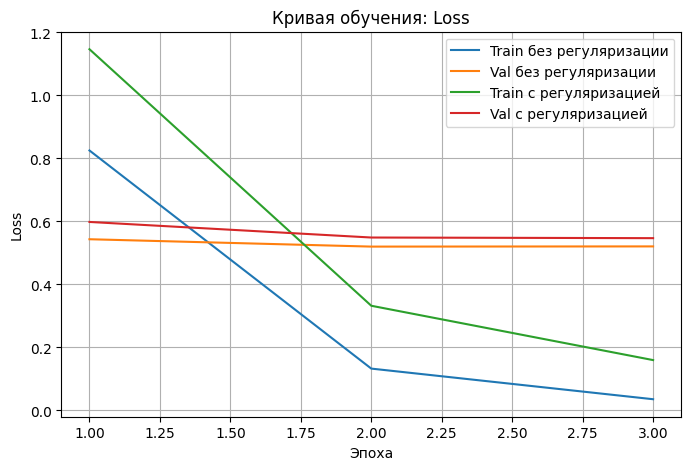


Сравнение метрик
-----------------------------------------------------------------
Модель                   Accuracy  Precision     Recall  Время (с)
-----------------------------------------------------------------
Без регуляризации          0.8250     0.8286     0.8250      122.6
С регуляризацией           0.8350     0.8367     0.8350      121.8
-----------------------------------------------------------------


In [18]:
# Accuracy
plt.figure(figsize=(8, 5))

ep_noreg = range(1, len(histories_reg['Без регуляризации']['accuracy']) + 1)
ep_reg   = range(1, len(histories_reg['С регуляризацией']['accuracy']) + 1)

plt.plot(ep_noreg, histories_reg['Без регуляризации']['accuracy'],
         label='Train без регуляризации')
plt.plot(ep_noreg, histories_reg['Без регуляризации']['val_accuracy'],
         label='Val без регуляризации')

plt.plot(ep_reg, histories_reg['С регуляризацией']['accuracy'],
         label='Train с регуляризацией')
plt.plot(ep_reg, histories_reg['С регуляризацией']['val_accuracy'],
         label='Val с регуляризацией')

plt.title('Кривая обучения: Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss
plt.figure(figsize=(8, 5))

ep_noreg = range(1, len(histories_reg['Без регуляризации']['loss']) + 1)
ep_reg   = range(1, len(histories_reg['С регуляризацией']['loss']) + 1)

plt.plot(ep_noreg, histories_reg['Без регуляризации']['loss'],
         label='Train без регуляризации')
plt.plot(ep_noreg, histories_reg['Без регуляризации']['val_loss'],
         label='Val без регуляризации')

plt.plot(ep_reg, histories_reg['С регуляризацией']['loss'],
         label='Train с регуляризацией')
plt.plot(ep_reg, histories_reg['С регуляризацией']['val_loss'],
         label='Val с регуляризацией')

plt.title('Кривая обучения: Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Истинные классы
y_true = np.argmax(y_test, axis=1)

# Предсказания моделей
y_pred_noreg = np.argmax(model_noreg.predict(X_test, verbose=0), axis=1)
y_pred_reg   = np.argmax(model_reg.predict(X_test, verbose=0), axis=1)

# Метрики
acc_noreg  = np.mean(y_pred_noreg == y_true)
prec_noreg = precision_score(y_true, y_pred_noreg, average='weighted', zero_division=0)
rec_noreg  = recall_score(y_true, y_pred_noreg, average='weighted', zero_division=0)

acc_reg  = np.mean(y_pred_reg == y_true)
prec_reg = precision_score(y_true, y_pred_reg, average='weighted', zero_division=0)
rec_reg  = recall_score(y_true, y_pred_reg, average='weighted', zero_division=0)

print("\nСравнение метрик")
print("-" * 65)
print(f"{'Модель':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'Время (с)':>10}")
print("-" * 65)
print(f"{'Без регуляризации':<22} {acc_noreg:>10.4f} {prec_noreg:>10.4f} {rec_noreg:>10.4f} {time_noreg:>10.1f}")
print(f"{'С регуляризацией':<22} {acc_reg:>10.4f} {prec_reg:>10.4f} {rec_reg:>10.4f} {time_reg:>10.1f}")
print("-" * 65)

**Вывод**
совместное применение CutMix и DropBlock+L2 даёт наилучший результат по val accuracy и устойчивость к переобучению при минимальном росте вычислительных затрат.

# Часть 4.2

In [19]:
# Grad-CAM, Saliency, Guided Backprop 

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras import Model

TARGET_MODEL = model_reg
IMG_SIZE = X_test.shape[1]
LAST_CONV = 'conv5_block3_out'   # последний conv-слой ResNet50

# 1. Вспомогательная функция для отображения изображений

def to_display_image(img):
    """
    Приводит изображение к виду, удобному для imshow.
    Работает и для обычных [0,1], и для preprocess_input-подобных данных.
    """
    img = img.copy()

    # Если изображение похоже на preprocess_input от ResNet50,
    # просто нормируем его в [0,1]
    img_min, img_max = img.min(), img.max()
    if img_min < 0 or img_max > 1:
        img = (img - img_min) / (img_max - img_min + 1e-8)

    return np.clip(img, 0, 1)

# 2. Grad-CAM

def grad_cam(model, img, class_idx=None, layer_name=LAST_CONV):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    img_tensor = tf.cast(img[np.newaxis], tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)[0]            # H x W x C
    conv_out = conv_out[0]

    weights = tf.reduce_mean(grads, axis=(0, 1))        # C
    cam = tf.reduce_sum(conv_out * weights, axis=-1)

    cam = tf.maximum(cam, 0)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., tf.newaxis], [IMG_SIZE, IMG_SIZE]).numpy()[..., 0]

    return cam

# 3. Saliency Map

def saliency_map(model, img, class_idx=None):
    img_tensor = tf.cast(img[np.newaxis], tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor, training=False)
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, img_tensor)[0].numpy()
    sal = np.max(np.abs(grads), axis=-1)
    sal = sal / (sal.max() + 1e-8)

    return sal

# 4. Guided Backprop (упрощённый вариант)

def guided_backprop(model, img, class_idx=None):
    img_tensor = tf.cast(img[np.newaxis], tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor, training=False)
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, img_tensor)[0].numpy()
    gbp = np.maximum(grads, 0)

    gbp = gbp - gbp.min()
    gbp = gbp / (gbp.max() + 1e-8)

    return gbp

# 5. Выбор нескольких тестовых изображений

sample_classes = [0, 1, 3, 5]   # airplane, automobile, cat, dog
sample_imgs = []
sample_true = []

y_true_all = np.argmax(y_test, axis=1)

for cls in sample_classes:
    idxs = np.where(y_true_all == cls)[0]
    sample_imgs.append(X_test[idxs[0]])
    sample_true.append(cls)

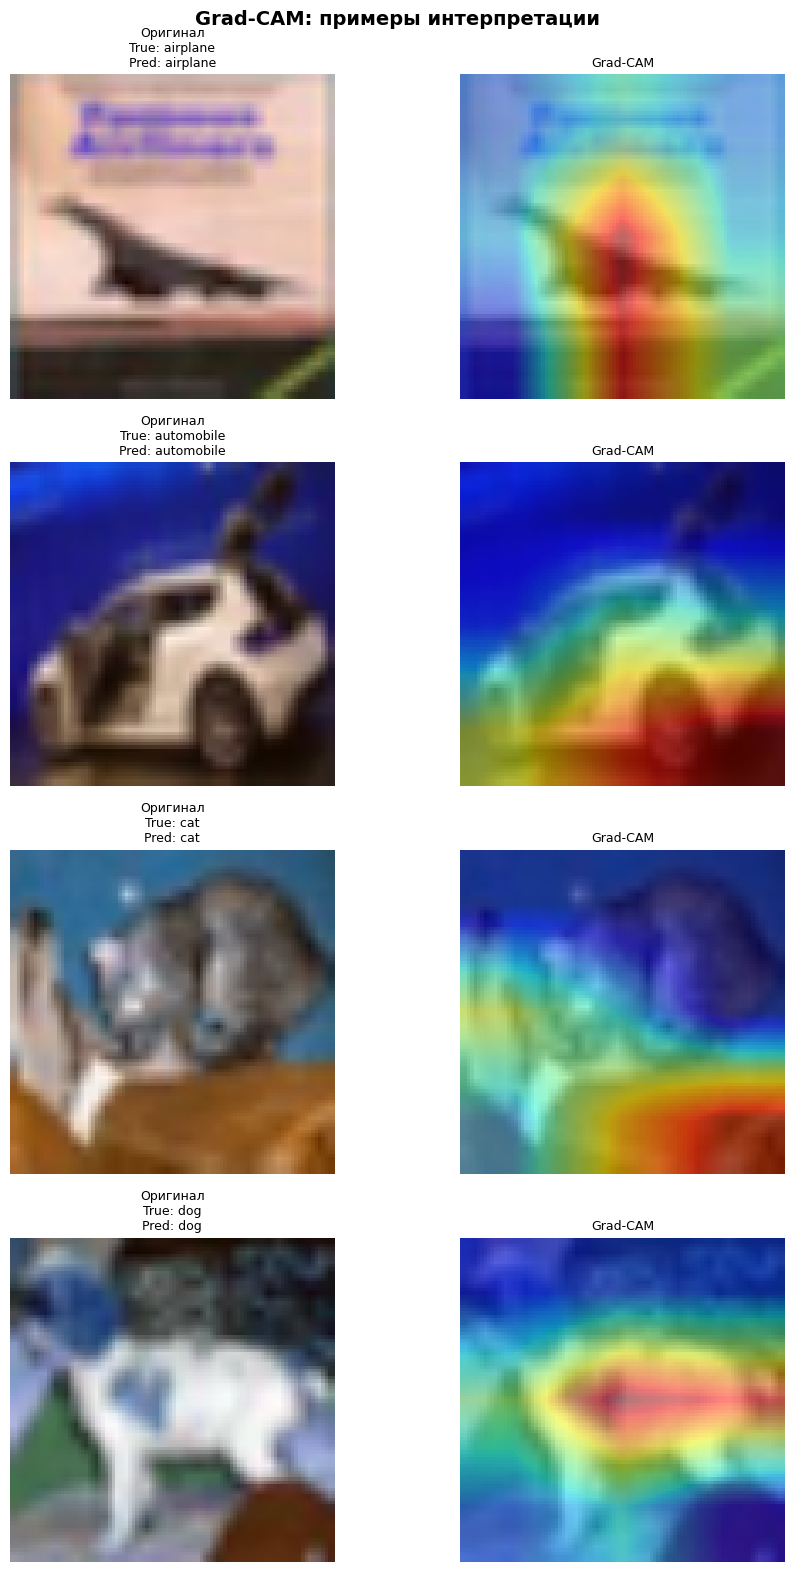

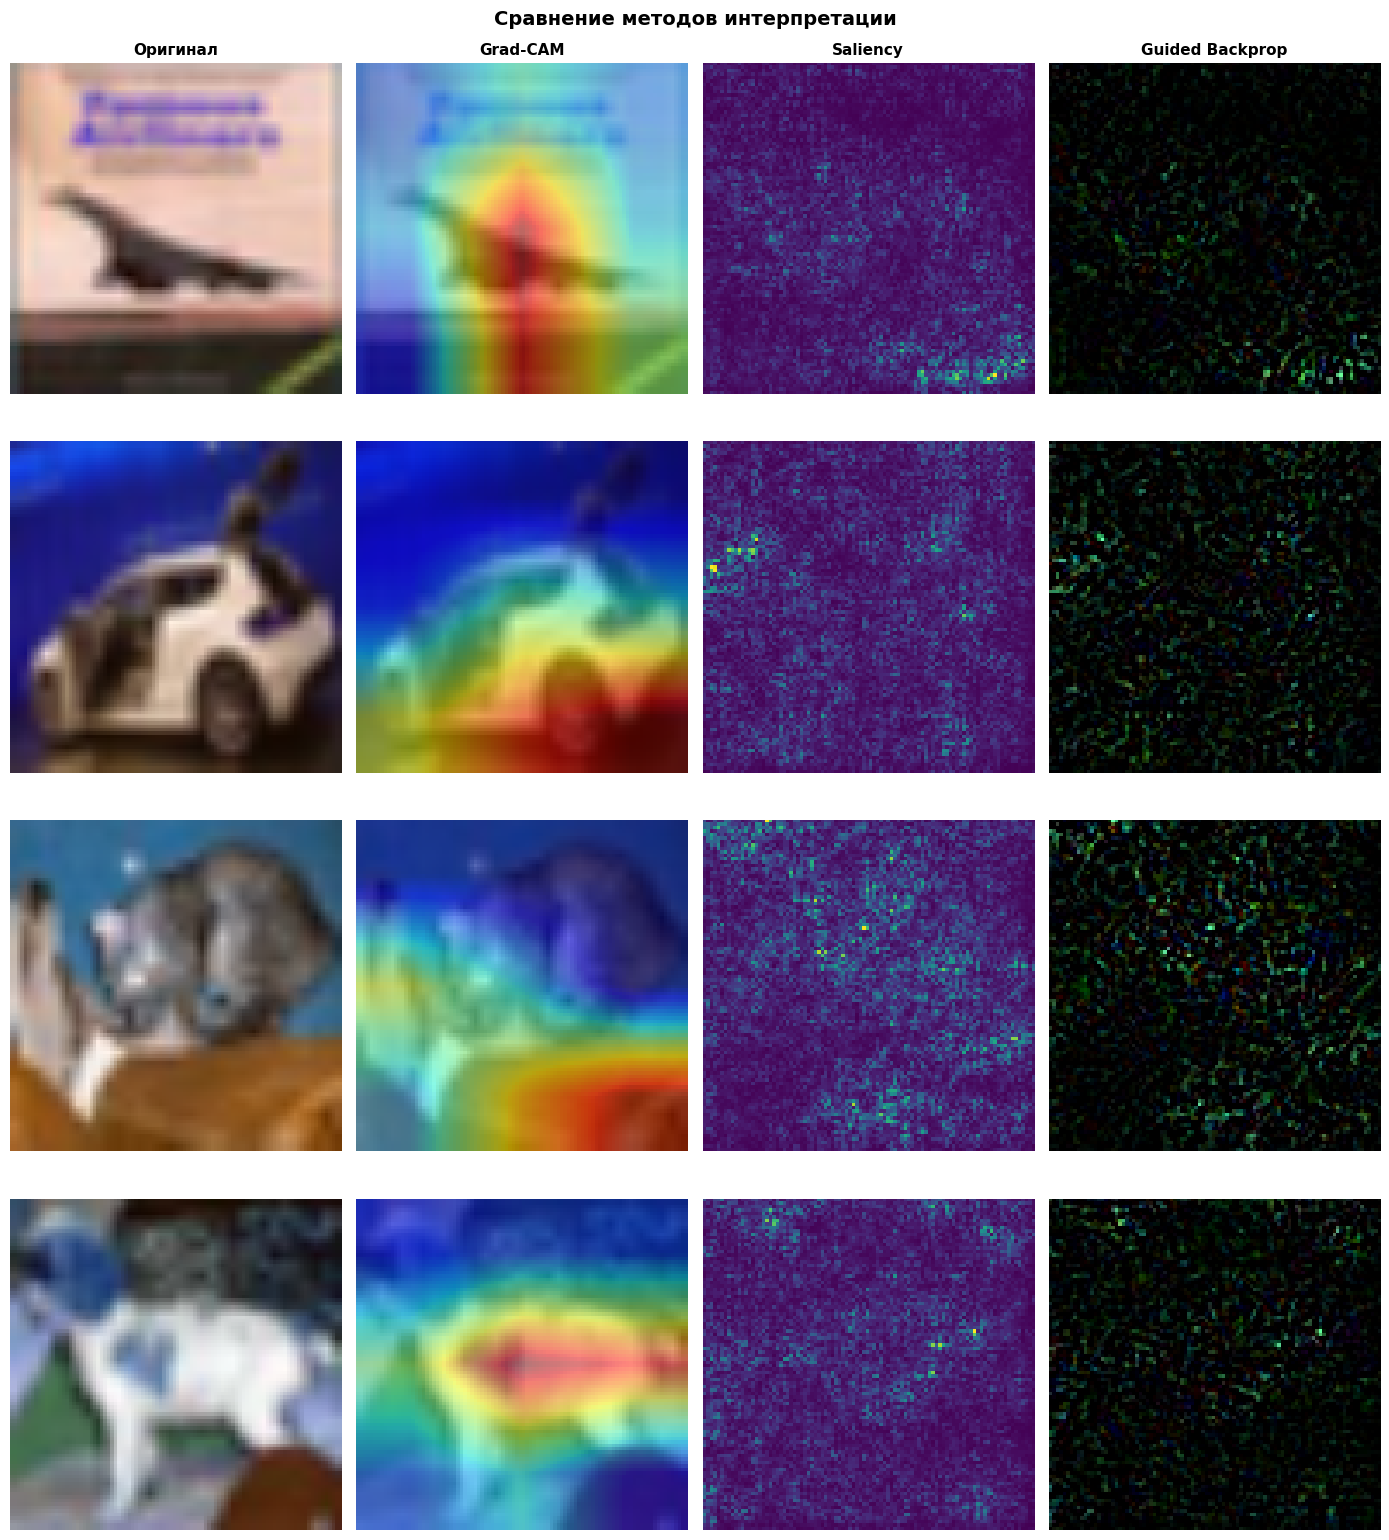

In [20]:
# Визуализация 1: Grad-CAM на нескольких примерах

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(10, 4 * len(sample_imgs)))
fig.suptitle('Grad-CAM: примеры интерпретации', fontsize=14, fontweight='bold')

for row, (img, true_cls) in enumerate(zip(sample_imgs, sample_true)):
    pred_probs = TARGET_MODEL.predict(img[np.newaxis], verbose=0)[0]
    pred_cls = int(np.argmax(pred_probs))

    cam = grad_cam(TARGET_MODEL, img, pred_cls)
    img_show = to_display_image(img)
    heatmap = cm.jet(cam)[..., :3]
    overlay = np.clip(0.5 * img_show + 0.5 * heatmap, 0, 1)

    axes[row, 0].imshow(img_show)
    axes[row, 0].set_title(
        f'Оригинал\nTrue: {CLASS_NAMES[true_cls]}\nPred: {CLASS_NAMES[pred_cls]}',
        fontsize=9
    )
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title('Grad-CAM', fontsize=9)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

# Визуализация 2: Сравнение методов

N_COMPARE = len(sample_imgs)

fig, axes = plt.subplots(N_COMPARE, 4, figsize=(14, 4 * N_COMPARE))
fig.suptitle('Сравнение методов интерпретации', fontsize=14, fontweight='bold')

col_titles = ['Оригинал', 'Grad-CAM', 'Saliency', 'Guided Backprop']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=11, fontweight='bold')

for row in range(N_COMPARE):
    img = sample_imgs[row]
    true_cls = sample_true[row]

    pred_probs = TARGET_MODEL.predict(img[np.newaxis], verbose=0)[0]
    pred_cls = int(np.argmax(pred_probs))

    cam = grad_cam(TARGET_MODEL, img, pred_cls)
    sal = saliency_map(TARGET_MODEL, img, pred_cls)
    gbp = guided_backprop(TARGET_MODEL, img, pred_cls)

    img_show = to_display_image(img)
    gradcam_overlay = np.clip(0.5 * img_show + 0.5 * cm.jet(cam)[..., :3], 0, 1)
    saliency_vis = cm.viridis(sal)[..., :3]
    gbp_vis = np.clip(gbp, 0, 1)

    visuals = [
        img_show,
        gradcam_overlay,
        saliency_vis,
        gbp_vis
    ]

    for col, vis in enumerate(visuals):
        axes[row, col].imshow(vis)
        axes[row, col].axis('off')

        if col == 0:
            axes[row, col].set_ylabel(
                f'True: {CLASS_NAMES[true_cls]}\nPred: {CLASS_NAMES[pred_cls]}',
                fontsize=8
            )

plt.tight_layout()
plt.show()

In [21]:
# Ablation Study — важность фильтров

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model

TARGET_MODEL = model_reg
ABLATION_LAYER = LAST_CONV
N_FILTERS_TEST = 32
N_EVAL_SAMPLES = 300
TOP_K = 10

X_eval = X_test[:N_EVAL_SAMPLES]
y_eval = y_test[:N_EVAL_SAMPLES]
y_true_eval = np.argmax(y_eval, axis=1)

# Базовая точность
base_preds = TARGET_MODEL.predict(X_eval, verbose=0)
base_acc = np.mean(np.argmax(base_preds, axis=1) == y_true_eval)

print(f"Базовая accuracy на {N_EVAL_SAMPLES} сэмплах: {base_acc:.4f}")
# Модель для получения активаций целевого слоя

feature_model = Model(
    inputs=TARGET_MODEL.input,
    outputs=TARGET_MODEL.get_layer(ABLATION_LAYER).output
)

print("Вычисление карт активаций...")
act_maps = feature_model.predict(X_eval, verbose=0)   # shape: N x H x W x C

n_filters = act_maps.shape[-1]
test_filters = np.random.choice(
    n_filters,
    size=min(N_FILTERS_TEST, n_filters),
    replace=False
)

print(f"Тестируем {len(test_filters)} фильтров из {n_filters}")
# Хвост модели: от выбранного conv-слоя до выхода
# Этот способ хорошо работает, если ABLATION_LAYER — последний conv-слой,
# и после него идёт обычная "голова" модели.

tail_input = tf.keras.Input(shape=act_maps.shape[1:])
x = tail_input
found_target = False

for layer in TARGET_MODEL.layers:
    if layer.name == ABLATION_LAYER:
        found_target = True
        continue

    if found_target:
        x = layer(x)

tail_model = Model(inputs=tail_input, outputs=x)

print("Ablation study")
drop_in_acc = []

for i, filt_idx in enumerate(test_filters):
    ablated_maps = act_maps.copy()
    ablated_maps[..., filt_idx] = 0.0   # обнуляем один фильтр

    preds_abl = tail_model.predict(ablated_maps, verbose=0)
    acc_abl = np.mean(np.argmax(preds_abl, axis=1) == y_true_eval)

    drop = base_acc - acc_abl
    drop_in_acc.append(drop)

    if (i + 1) % 8 == 0 or (i + 1) == len(test_filters):
        print(f"  Обработано {i+1}/{len(test_filters)} фильтров")

drop_in_acc = np.array(drop_in_acc)

# Сортировка по важности
sorted_idx = np.argsort(drop_in_acc)[::-1]
top_filters = test_filters[sorted_idx[:TOP_K]]
top_drops = drop_in_acc[sorted_idx[:TOP_K]]

print("\nТоп самых важных фильтров:")
for filt, drop in zip(top_filters, top_drops):
    print(f"Filter #{filt:<4} | падение accuracy: {drop:.4f}")

Базовая accuracy на 300 сэмплах: 0.8233
Вычисление карт активаций...
Тестируем 32 фильтров из 2048
Ablation study
  Обработано 8/32 фильтров
  Обработано 16/32 фильтров
  Обработано 24/32 фильтров
  Обработано 32/32 фильтров

Топ самых важных фильтров:
Filter #2013 | падение accuracy: 0.0033
Filter #1076 | падение accuracy: 0.0033
Filter #148  | падение accuracy: 0.0000
Filter #457  | падение accuracy: 0.0000
Filter #1267 | падение accuracy: 0.0000
Filter #103  | падение accuracy: 0.0000
Filter #2007 | падение accuracy: 0.0000
Filter #1866 | падение accuracy: 0.0000
Filter #50   | падение accuracy: 0.0000
Filter #78   | падение accuracy: 0.0000


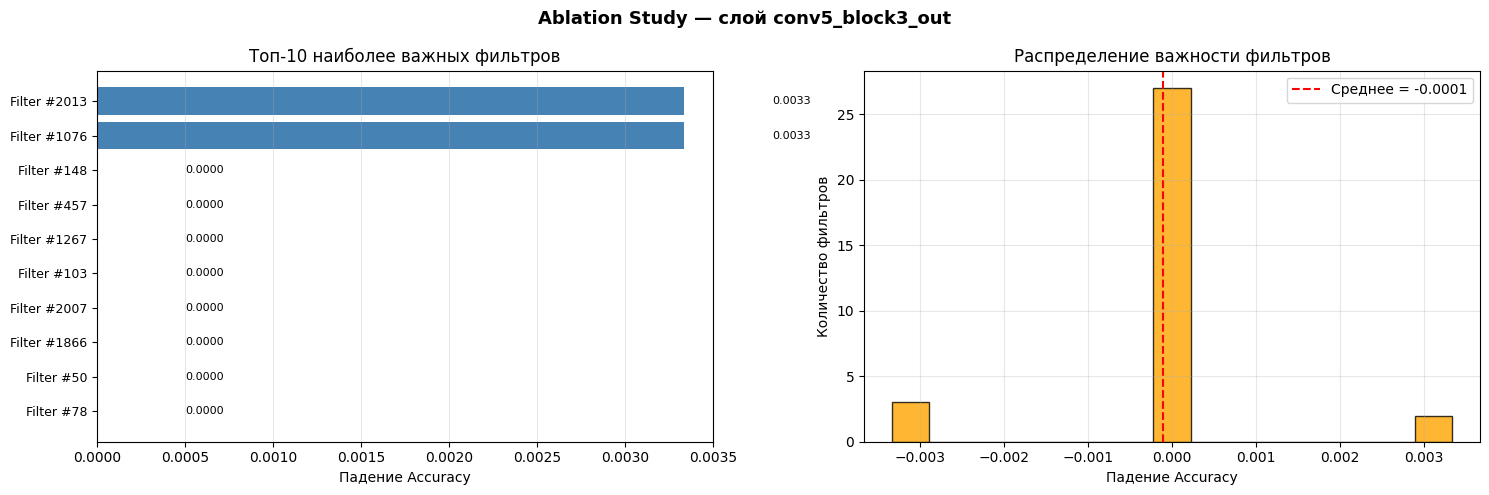

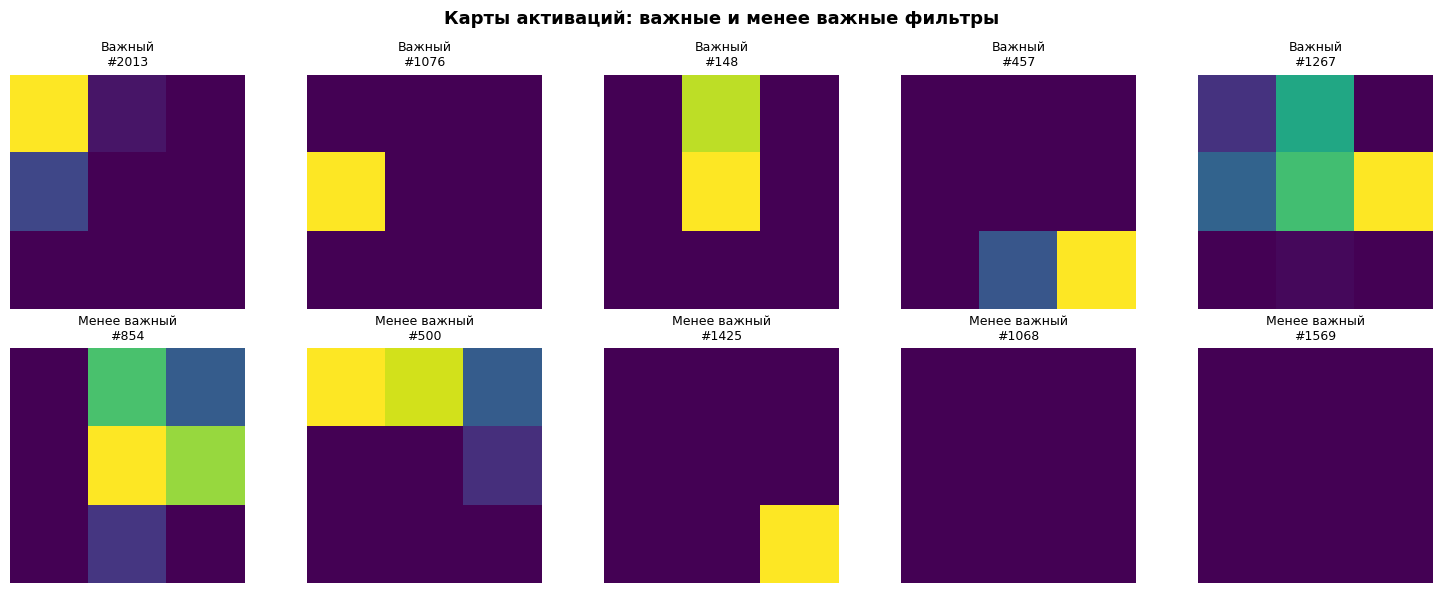

In [22]:
# Визуализация: важность фильтров

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Ablation Study — слой {ABLATION_LAYER}', fontsize=13, fontweight='bold')

# Топ важных фильтров
axes[0].barh(range(len(top_filters))[::-1], top_drops, color='steelblue')
axes[0].set_yticks(range(len(top_filters))[::-1])
axes[0].set_yticklabels([f'Filter #{f}' for f in top_filters], fontsize=9)
axes[0].set_xlabel('Падение Accuracy')
axes[0].set_title(f'Топ-{TOP_K} наиболее важных фильтров')
axes[0].grid(axis='x', alpha=0.3)

for i, value in enumerate(top_drops):
    axes[0].text(value + 0.0005, len(top_filters) - 1 - i, f'{value:.4f}',
                 va='center', fontsize=8)

# Распределение важности
axes[1].hist(drop_in_acc, bins=15, color='orange', edgecolor='black', alpha=0.8)
axes[1].axvline(drop_in_acc.mean(), color='red', linestyle='--',
                label=f'Среднее = {drop_in_acc.mean():.4f}')
axes[1].set_xlabel('Падение Accuracy')
axes[1].set_ylabel('Количество фильтров')
axes[1].set_title('Распределение важности фильтров')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
# Визуализация карт активаций

# Берём одно изображение для просмотра activation maps
sample_img = X_eval[0:1]
sample_act = feature_model.predict(sample_img, verbose=0)[0]

top5_important = test_filters[sorted_idx[:5]]
top5_unimportant = test_filters[sorted_idx[-5:]]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Карты активаций: важные и менее важные фильтры',
             fontsize=13, fontweight='bold')

for col in range(5):
    # Важные фильтры
    fmap_imp = sample_act[..., top5_important[col]]
    axes[0, col].imshow(fmap_imp, cmap='viridis')
    axes[0, col].set_title(f'Важный\n#{top5_important[col]}', fontsize=9)
    axes[0, col].axis('off')

    # Менее важные фильтры
    fmap_unimp = sample_act[..., top5_unimportant[col]]
    axes[1, col].imshow(fmap_unimp, cmap='viridis')
    axes[1, col].set_title(f'Менее важный\n#{top5_unimportant[col]}', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

In [23]:
#  Adversarial Attacks (FGSM, PGD) — упрощённо
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# Вспомогательные функции
def to_display_image(img):
    """
    Делает изображение пригодным для imshow.
    Подходит и для обычных [0,1], и для preprocess_input-подобных данных.
    """
    img = img.copy()
    img_min, img_max = img.min(), img.max()

    if img_min < 0 or img_max > 1:
        img = (img - img_min) / (img_max - img_min + 1e-8)

    return np.clip(img, 0, 1)

# Глобальные границы данных
DATA_MIN = float(np.min(X_test))
DATA_MAX = float(np.max(X_test))

def clip_like_data(x):
    return tf.clip_by_value(x, DATA_MIN, DATA_MAX)



# FGSM
def fgsm_attack(model, img, true_label, epsilon=0.01):
    img_t = tf.cast(img[np.newaxis], tf.float32)
    lbl_t = tf.cast(true_label[np.newaxis], tf.float32)

    loss_fn = tf.keras.losses.CategoricalCrossentropy()

    with tf.GradientTape() as tape:
        tape.watch(img_t)
        preds = model(img_t, training=False)
        loss = loss_fn(lbl_t, preds)

    grad = tape.gradient(loss, img_t)
    adv_img = img_t + epsilon * tf.sign(grad)
    adv_img = clip_like_data(adv_img)

    return adv_img[0].numpy()



# PGD
def pgd_attack(model, img, true_label, epsilon=0.01, alpha=0.003, n_steps=5):
    img_t = tf.cast(img[np.newaxis], tf.float32)
    lbl_t = tf.cast(true_label[np.newaxis], tf.float32)

    loss_fn = tf.keras.losses.CategoricalCrossentropy()

    adv = img_t + tf.random.uniform(img_t.shape, -epsilon, epsilon)
    adv = clip_like_data(adv)

    for _ in range(n_steps):
        adv_var = tf.Variable(adv)

        with tf.GradientTape() as tape:
            preds = model(adv_var, training=False)
            loss = loss_fn(lbl_t, preds)

        grad = tape.gradient(loss, adv_var)
        adv = adv_var + alpha * tf.sign(grad)

        # Ограничиваем отклонение от оригинала
        adv = tf.clip_by_value(adv, img_t - epsilon, img_t + epsilon)
        adv = clip_like_data(adv)

    return adv[0].numpy()



# Выбор нескольких корректно классифицированных изображений
N_ADV = 6
epsilons = [0.005, 0.01, 0.03]

y_true_all = np.argmax(y_test, axis=1)
preds_clean = np.argmax(TARGET_MODEL.predict(X_test[:200], verbose=0), axis=1)

correct_idx = np.where(preds_clean == y_true_all[:200])[0][:N_ADV]

adv_results = []
print("Генерация adversarial примеров")

for idx in correct_idx:
    img = X_test[idx]
    lbl = y_test[idx]

    fgsm_dict = {}
    pgd_dict = {}

    for eps in epsilons:
        fgsm_dict[eps] = fgsm_attack(TARGET_MODEL, img, lbl, epsilon=eps)
        pgd_dict[eps] = pgd_attack(TARGET_MODEL, img, lbl, epsilon=eps, alpha=eps/3, n_steps=5)

    adv_results.append((img, lbl, fgsm_dict, pgd_dict))
    print(f"Пример {idx} обработан")

Генерация adversarial примеров
Пример 0 обработан
Пример 1 обработан
Пример 2 обработан
Пример 3 обработан
Пример 4 обработан
Пример 5 обработан


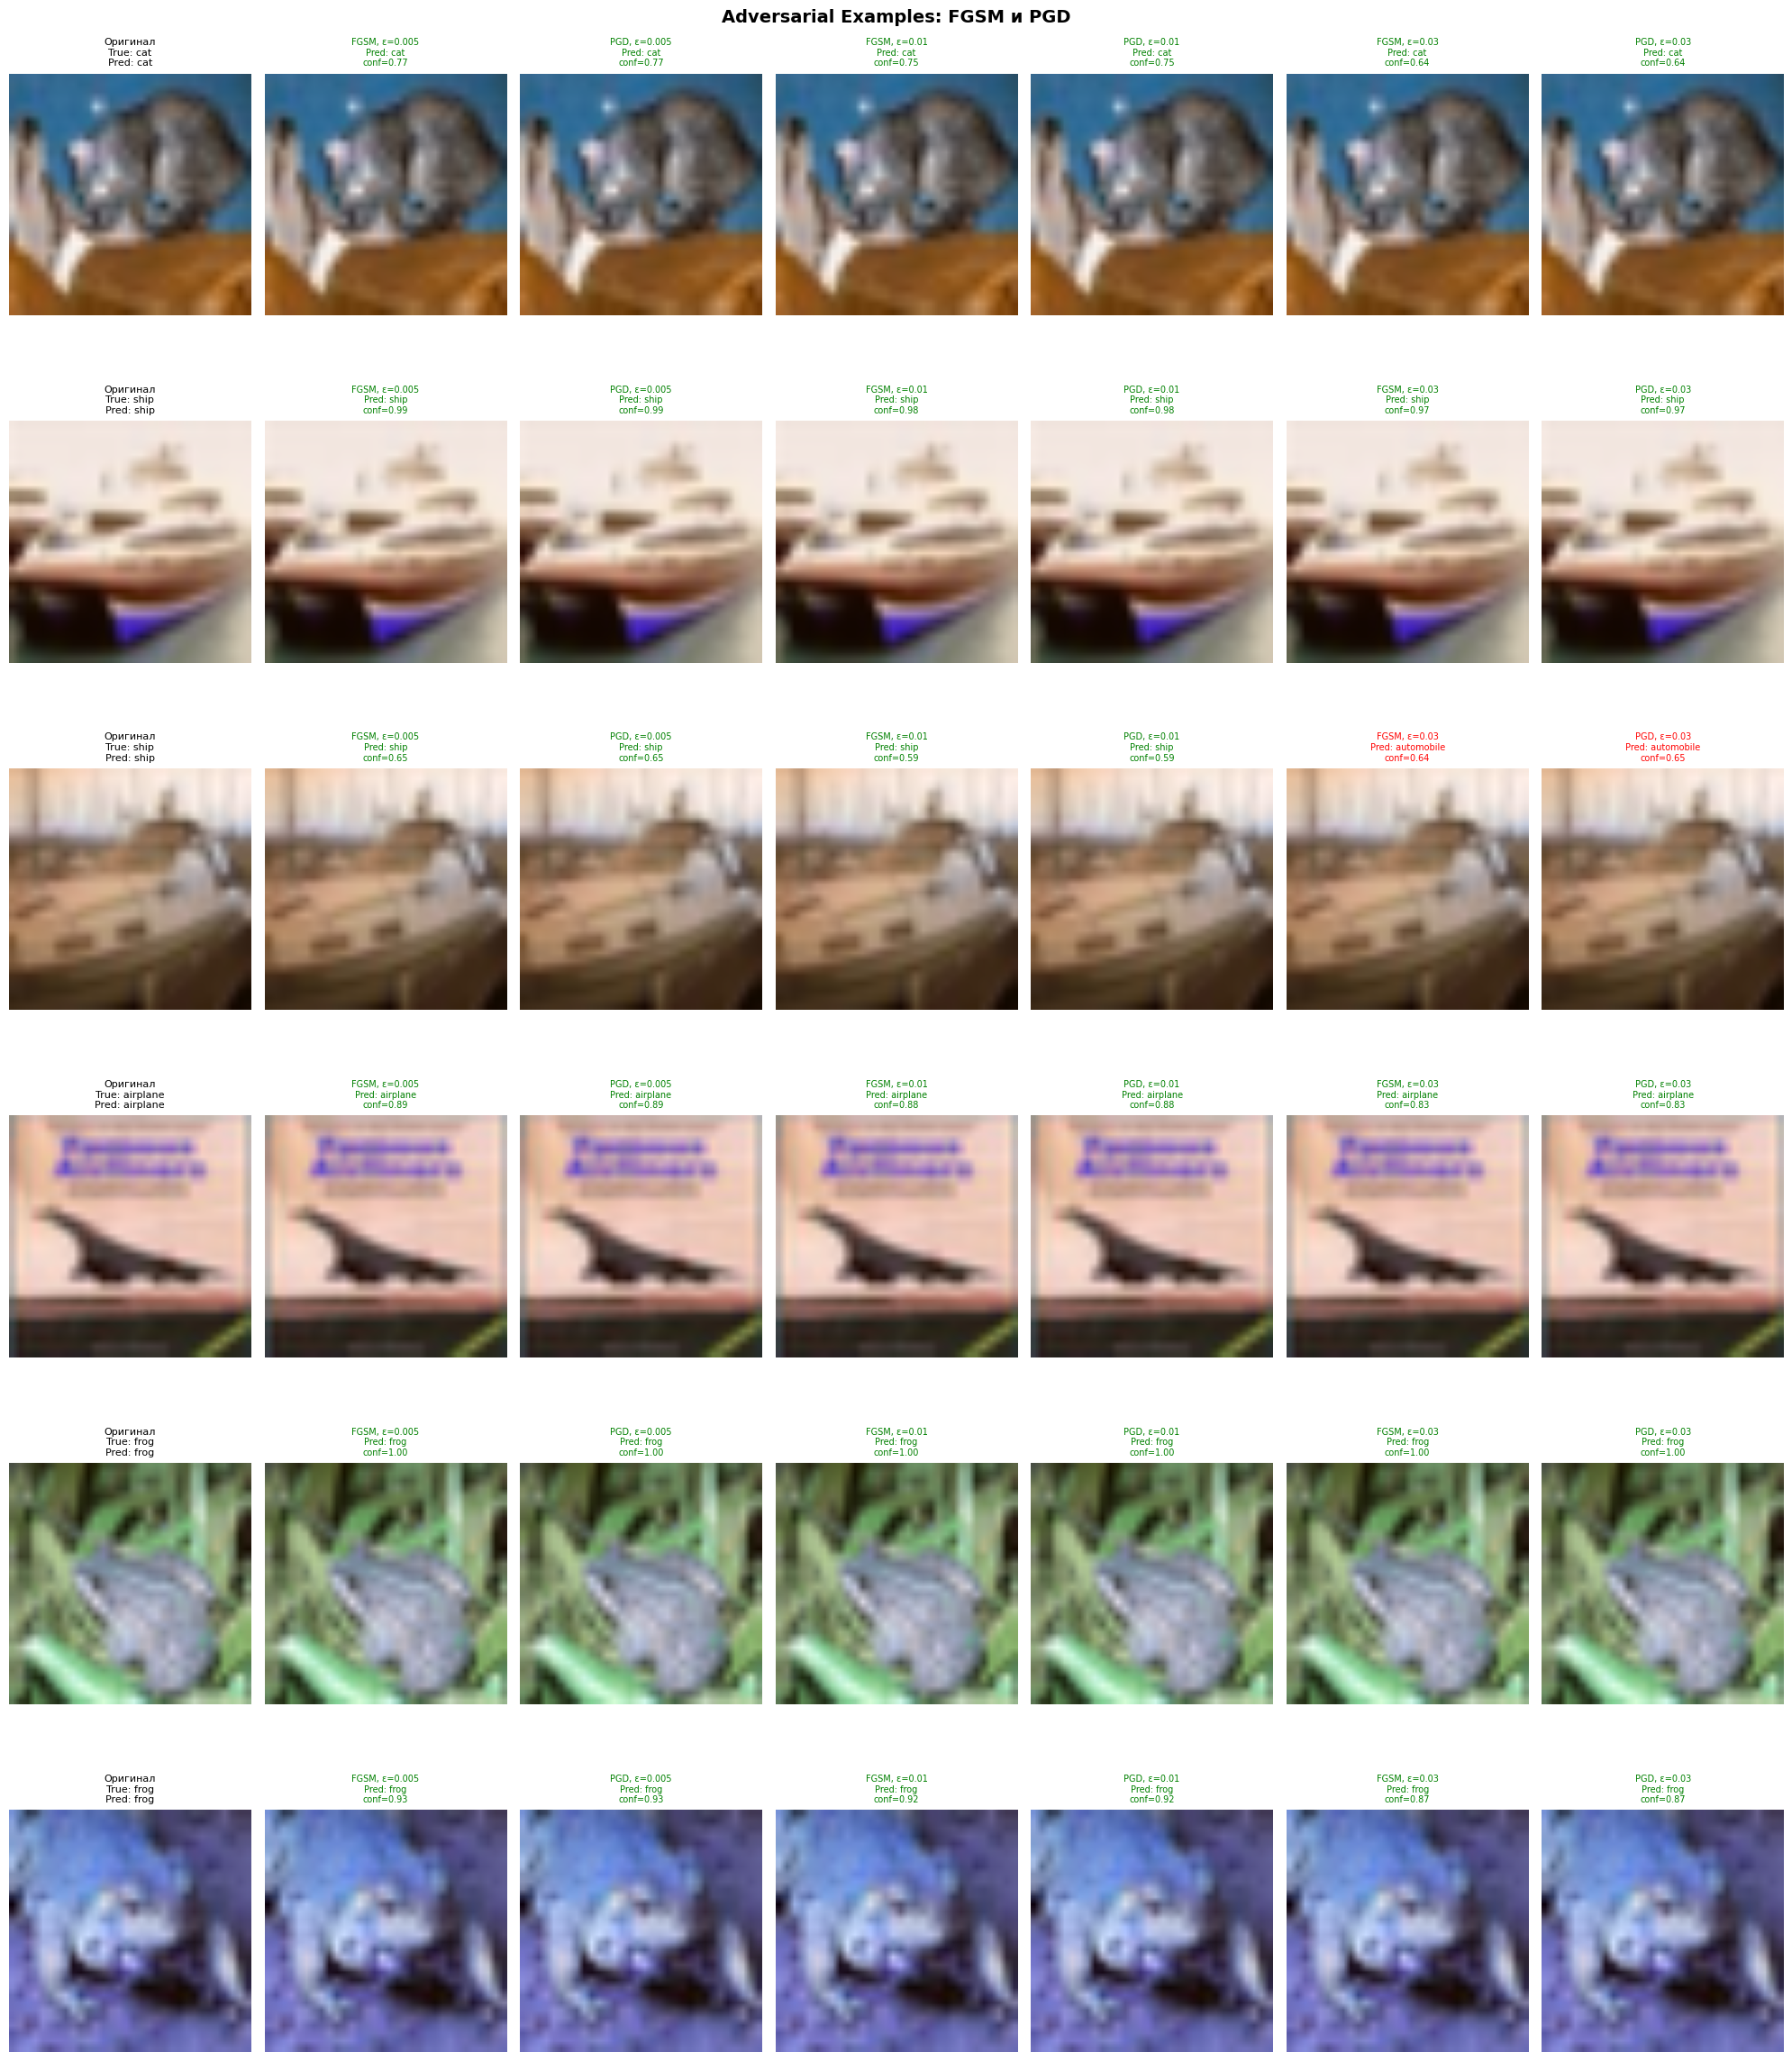


Оценка устойчивости модели
ε=0.000 | FGSM acc=0.900 | PGD acc=0.900
ε=0.007 | FGSM acc=0.900 | PGD acc=0.900
ε=0.014 | FGSM acc=0.900 | PGD acc=0.900
ε=0.021 | FGSM acc=0.880 | PGD acc=0.880
ε=0.029 | FGSM acc=0.840 | PGD acc=0.840
ε=0.036 | FGSM acc=0.840 | PGD acc=0.840
ε=0.043 | FGSM acc=0.840 | PGD acc=0.840
ε=0.050 | FGSM acc=0.820 | PGD acc=0.820


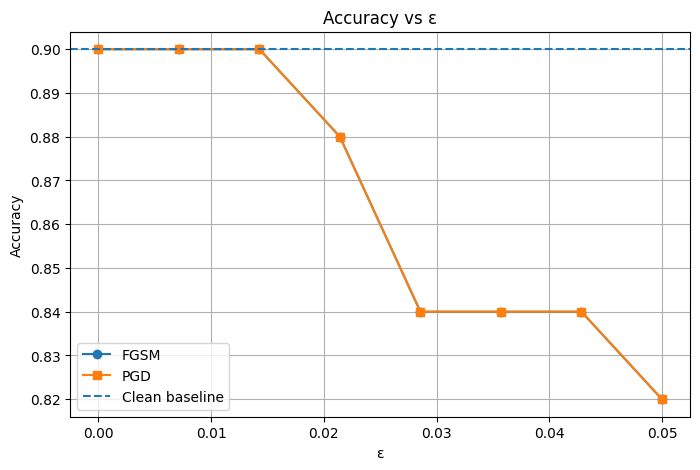

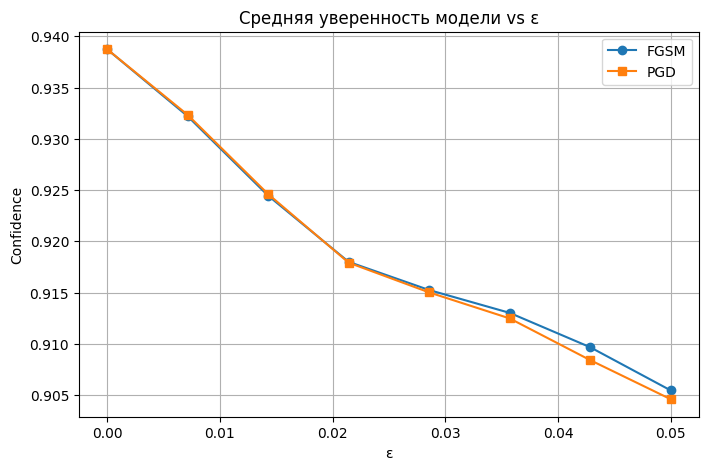

In [24]:
# Визуализация adversarial-примеров

n_cols = 1 + 2 * len(epsilons)   # оригинал + FGSM/PGD для каждого epsilon
fig, axes = plt.subplots(len(adv_results), n_cols, figsize=(20, 4 * len(adv_results)))
fig.suptitle('Adversarial Examples: FGSM и PGD', fontsize=14, fontweight='bold')

if len(adv_results) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (orig, lbl, fgsm_dict, pgd_dict) in enumerate(adv_results):
    true_cls = np.argmax(lbl)

    # Оригинал
    clean_probs = TARGET_MODEL.predict(orig[np.newaxis], verbose=0)[0]
    pred_clean = np.argmax(clean_probs)

    axes[row, 0].imshow(to_display_image(orig))
    axes[row, 0].set_title(
        f'Оригинал\nTrue: {CLASS_NAMES[true_cls]}\nPred: {CLASS_NAMES[pred_clean]}',
        fontsize=8
    )
    axes[row, 0].axis('off')

    col = 1
    for eps in epsilons:
        for method_name, adv_img in [('FGSM', fgsm_dict[eps]), ('PGD', pgd_dict[eps])]:
            probs = TARGET_MODEL.predict(adv_img[np.newaxis], verbose=0)[0]
            pred_cls = np.argmax(probs)

            axes[row, col].imshow(to_display_image(adv_img))
            axes[row, col].set_title(
                f'{method_name}, ε={eps}\nPred: {CLASS_NAMES[pred_cls]}\nconf={probs[pred_cls]:.2f}',
                fontsize=7,
                color='green' if pred_cls == true_cls else 'red'
            )
            axes[row, col].axis('off')
            col += 1

plt.tight_layout()
plt.show()


# Accuracy vs epsilon и confidence vs epsilon
eps_range = np.linspace(0.0, 0.05, 8)

fgsm_accs = []
pgd_accs = []
fgsm_confs = []
pgd_confs = []

X_eval = X_test[:50]
y_eval = y_test[:50]
y_true_eval = np.argmax(y_eval, axis=1)

print("\nОценка устойчивости модели")

for eps in eps_range:
    fgsm_batch = []
    pgd_batch = []

    for i in range(len(X_eval)):
        fgsm_batch.append(fgsm_attack(TARGET_MODEL, X_eval[i], y_eval[i], epsilon=eps))
        pgd_batch.append(pgd_attack(TARGET_MODEL, X_eval[i], y_eval[i], epsilon=eps, alpha=max(eps/3, 1e-4), n_steps=5))

    fgsm_batch = np.array(fgsm_batch)
    pgd_batch = np.array(pgd_batch)

    preds_fgsm = TARGET_MODEL.predict(fgsm_batch, verbose=0)
    preds_pgd = TARGET_MODEL.predict(pgd_batch, verbose=0)

    fgsm_acc = np.mean(np.argmax(preds_fgsm, axis=1) == y_true_eval)
    pgd_acc = np.mean(np.argmax(preds_pgd, axis=1) == y_true_eval)

    fgsm_conf = np.mean(np.max(preds_fgsm, axis=1))
    pgd_conf = np.mean(np.max(preds_pgd, axis=1))

    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    fgsm_confs.append(fgsm_conf)
    pgd_confs.append(pgd_conf)

    print(f"ε={eps:.3f} | FGSM acc={fgsm_acc:.3f} | PGD acc={pgd_acc:.3f}")


# Базовая clean accuracy
clean_preds = TARGET_MODEL.predict(X_eval, verbose=0)
clean_acc = np.mean(np.argmax(clean_preds, axis=1) == y_true_eval)

# Простые графики

# Accuracy vs epsilon
plt.figure(figsize=(8, 5))
plt.plot(eps_range, fgsm_accs, marker='o', label='FGSM')
plt.plot(eps_range, pgd_accs, marker='s', label='PGD')
plt.axhline(clean_acc, linestyle='--', label='Clean baseline')
plt.title('Accuracy vs ε')
plt.xlabel('ε')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Confidence vs epsilon
plt.figure(figsize=(8, 5))
plt.plot(eps_range, fgsm_confs, marker='o', label='FGSM')
plt.plot(eps_range, pgd_confs, marker='s', label='PGD')
plt.title('Средняя уверенность модели vs ε')
plt.xlabel('ε')
plt.ylabel('Confidence')
plt.legend()
plt.grid(True)
plt.show()

**Общий итог**: интерпретируемость и устойчивость — две стороны одной медали. Модель, чьё внимание совпадает с человеческим восприятием (Grad-CAM), как правило, более устойчива к атакам. Для повышения robustness рекомендуется adversarial training и прунинг незначимых фильтров по результатам ablation.

## Ответы на вопросы

### Почему сверточные слои более эффективны для изображений, чем полносвязные?

Сверточные слои лучше подходят для изображений, потому что они используют локальные фильтры и учитывают пространственную структуру данных. Один и тот же фильтр применяется ко всему изображению, поэтому сеть распознаёт одинаковые признаки в разных местах кадра. Это значительно уменьшает число параметров по сравнению с полносвязными слоями и делает обучение более эффективным.

### Как работает Batch Normalization и почему она важна для глубоких CNN?

Batch Normalization нормализует выходы слоя внутри мини-батча, делая распределение активаций более стабильным. После нормализации применяются обучаемые параметры масштаба и сдвига. Это ускоряет обучение, уменьшает риск нестабильности градиентов и позволяет использовать более высокие learning rate. В глубоких CNN Batch Normalization особенно важна для устойчивого и быстрого обучения.

### Как выбрать оптимальную стратегию transfer learning?

Выбор зависит от объёма данных и их похожести на датасет, на котором была предобучена модель. Если данных мало и они похожи на ImageNet, часто достаточно заморозить backbone и обучить только классификационную голову. Если данных больше или изображения сильно отличаются по домену, лучше разморозить верхние слои и применить fine-tuning с маленьким learning rate. Оптимальный вариант обычно выбирают экспериментально по качеству на валидации.

### Какие метрики важны для оценки CNN кроме точности?

Помимо accuracy, важны precision, recall и F1-score, особенно при несбалансированных классах. Также полезна confusion matrix, потому что она показывает, какие классы модель путает чаще всего. В задачах, где важны вероятностные оценки, дополнительно используют ROC-AUC, PR-AUC и log loss.

### Как оценить важность различных аугментаций для конкретного датасета?

Для этого обычно проводят контролируемый эксперимент: обучают одну и ту же модель с одинаковыми параметрами, изменяя только набор аугментаций. Затем сравнивают метрики на validation/test выборке. Если аугментация улучшает качество и уменьшает переобучение, значит она полезна для данного датасета. Если качество падает, значит такая аугментация либо слишком сильная, либо не соответствует природе данных.